# MiniGrid RL Results

Plots a metric over the course of training for our reinforcement learning runs, grouped by how the model was
trained. Unlike the supervised notebooks, these results are indexed by environment timestep rather than by epoch,
so there are no epochs to summarize over -- we plot the whole trajectory.

# Imports

In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from utils.postprocess import load_result_dataframe

In [32]:
sns.set(font_scale=1.1, style="whitegrid")
pd.set_option("display.max_rows", 200)

# Scan Files

Find and load all result files. RL results carry no `metadata.yml`, so everything we group by is derived from the
run's directory instead (`include_location=True`).

In [33]:
proj_dir = Path("../experiments/poc")
full_df = load_result_dataframe(proj_dir, calc_sizes=False, meta_required=False, include_location=True)
print(f"{len(full_df)} rows from {full_df.index.get_level_values('location').nunique()} runs")
full_df.head()

100%|██████████| 220/220 [00:00<00:00, 621.52it/s]

115581 rows from 30 runs


Train/Reward  Train/Episode Length  \
location                      seed  Step                                       
babyai-go-to-red-ball-nodists 12345 1024      0.181543             53.312500   
                                    2048      0.178814             53.794118   
                                    3072      0.160531             54.860000   
                                    4096      0.165424             54.471429   
                                    5120      0.206250             51.829787   

                                          Train/Success Rate  Time/Step  \
location                      seed  Step                                  
babyai-go-to-red-ball-nodists 12345 1024            0.312500   0.183500   
                                    2048            0.352941   0.177623   
                                    3072            0.320000   0.175252   
                                    4096            0.314286   0.179288   
                                    5120            0.351064   0.180261   

                                             Time/FPS    Proc Mem  Time/Total  \
location                      seed  Step                                        
babyai-go-to-red-ball-nodists 12345 1024  5580.379905  392.062500    0.183772   
                                    2048  5765.018082  400.218750    1.344630   
                                    3072  5843.015939  401.328125    2.461417   
                                    4096  5711.476226  401.437500    3.573834   
                                    5120  5680.655199  401.609375    5.168399   

                                              Loss  Policy Loss  Value Loss  \
location                      seed  Step                                      
babyai-go-to-red-ball-nodists 12345 1024 -0.017423    -0.012594    0.082311   
                                    2048 -0.018206    -0.022331    0.025183   
                                    3072 -0.042125    -0.027175    0.013019   
                                    4096 -0.046703    -0.031069    0.013861   
                                    5120 -0.060367    -0.030576    0.017637   

                                          Approx KL  Clip Fraction  \
location                      seed  Step                             
babyai-go-to-red-ball-nodists 12345 1024   0.010607       0.049316   
                                    2048   0.012202       0.123438   
                                    3072   0.014068       0.104297   
                                    4096   0.015401       0.159766   
                                    5120   0.016051       0.175488   

                                          Explained Variance        LR  \
location                      seed  Step                                 
babyai-go-to-red-ball-nodists 12345 1024           -0.975246  0.000247   
                                    2048           -0.617793  0.000245   
                                    3072           -0.230830  0.000242   
                                    4096           -0.155016  0.000240   
                                    5120            0.198317  0.000237   

                                           Entropy  Eval/Reward  \
location                      seed  Step                          
babyai-go-to-red-ball-nodists 12345 1024  1.941187          NaN   
                                    2048  1.925221          NaN   
                                    3072  1.911049          NaN   
                                    4096  1.885824          NaN   
                                    5120  1.861829     0.143672   

                                          Eval/Episode Length  \
location                      seed  Step                        
babyai-go-to-red-ball-nodists 12345 1024                  NaN   
                                    2048                  NaN   
                                    3072                  NaN   
                            

# Parse Locations

Directory names vary too much to split by position, so we look for known keywords instead.

Everything **before the first `/`** names the run: `<benchmark>-<task>[-<train-method>]`. The benchmark is always
one word; the training method is matched against a known list (longest first, so `stitch-frozen` wins over
`stitch`) and defaults to `from-scratch` when absent; whatever is left is the task.

Everything **after the first `/`** is an attribute -- either a bare flag (`small-heads`) or a name and a value
(`ent-0.0`). Anything unrecognized is reported rather than silently folded into another field.

In [34]:
TRAIN_METHODS = [
    "pretrained-from-unlock",
    "pretrained-from-empty-random",
    "stitch-frozen",
    "stitch",
]
DEFAULT_METHOD = "from-scratch"  # What a location means when it names no method at all.

FLAGS = ["small-heads", "full-net", "with-norms"]  # Present in the path -> True, absent -> False.
NUMERIC_DEFAULTS = {"ent": 0.01}  # "<name>-<value>" in the path -> float. Otherwise this is the value used.

In [35]:
def _take(tokens, phrase):
    """ Remove `phrase` from `tokens` if it appears there as a run of consecutive tokens. """
    wanted = phrase.split("-")
    for i in range(len(tokens) - len(wanted) + 1):
        if tokens[i:i + len(wanted)] == wanted:
            return tokens[:i] + tokens[i + len(wanted):], True
    return tokens, False


def _is_number(token):
    try:
        float(token)
        return True
    except ValueError:
        return False


def parse_location(location):
    """ Turn a run's directory into the columns we group and facet by. See the note above for the format. """
    head, _, tail = str(location).partition("/")

    # Before the first "/": benchmark, then (optionally) a training method, and the rest is the task.
    tokens = head.split("-")
    benchmark, tokens = tokens[0], tokens[1:]
    method = DEFAULT_METHOD
    for candidate in sorted(TRAIN_METHODS, key=len, reverse=True):
        tokens, found = _take(tokens, candidate)
        if found:
            method = candidate
            break
    parsed = {"benchmark": benchmark, "task": "-".join(tokens), "train-method": method}

    # After the first "/": attributes only, so the task can never be polluted by one.
    tokens = [t for segment in tail.split("/") if segment for t in segment.split("-")]
    for flag in FLAGS:
        tokens, parsed[flag] = _take(tokens, flag)
    parsed.update(NUMERIC_DEFAULTS)
    unrecognized = []
    while tokens:
        if len(tokens) > 1 and _is_number(tokens[1]):
            parsed[tokens[0]] = float(tokens[1])
            tokens = tokens[2:]
        else:
            unrecognized.append(tokens.pop(0))
    if unrecognized:
        warnings.warn(f"Unrecognized parts of location {location!r}: {unrecognized}. Add them to FLAGS, "
                      "TRAIN_METHODS, or NUMERIC_DEFAULTS above.")
    return parsed

In [36]:
def add_location_columns(df):
    """ Prepend the parsed location fields as columns. """
    parsed = pd.DataFrame([parse_location(loc) for loc in df.index.get_level_values("location")], index=df.index)
    return pd.concat([parsed, df], axis=1)


df = add_location_columns(full_df)
# One row per run, to eyeball that every directory parsed the way we expect.
df.groupby(level="location").first()[["benchmark", "task", "train-method", *FLAGS, *NUMERIC_DEFAULTS]]

,benchmark,task,train-method,small-heads,full-net,with-norms,ent
location,,,,,,,
babyai-go-to-red-ball-nodists,babyai,go-to-red-ball-nodists,from-scratch,False,False,False,0.01
babyai-pickup-dist,babyai,pickup-dist,from-scratch,False,False,False,0.01
babyai-unlock,babyai,unlock,from-scratch,False,False,False,0.01
babyai-unlock-local,babyai,unlock-local,from-scratch,False,False,False,0.01
minigrid-doorkey,minigrid,doorkey,from-scratch,False,False,False,0.01
minigrid-doorkey-pretrained-from-empty-random,minigrid,doorkey,pretrained-from-empty-random,False,False,False,0.01
minigrid-doorkey-pretrained-from-empty-random/full-net,minigrid,doorkey,pretrained-from-empty-random,False,True,False,0.01
minigrid-doorkey-pretrained-from-empty-random/small-heads,minigrid,doorkey,pretrained-from-empty-random,True,False,False,0.01
minigrid-doorkey-pretrained-from-empty-random/small-heads-full-net,minigrid,doorkey,pretrained-from-empty-random,True,True,False,0.01


# Filters

- Select the environment we want to look at right now.
- Don't include non-optimal variants like runs with norms or with `ent_coef = 0.0`.
- Only show training up to the shortest training run.

In [37]:
BENCHMARK, TASK = "minigrid", "doorkey"

# Task focus
runs = df[(df["benchmark"] == BENCHMARK) & (df["task"] == TASK)]
# Filter non-optimal runs.
runs = runs[~runs["with-norms"]]
runs = runs[runs["ent"] == 0.01]
# Find the run w/ the lowest final step value.
max_step_per_run = runs.reset_index("Step").groupby(level="location").agg({"Step": "max"})
smallest_max = max_step_per_run.min().item()
runs = runs.loc[runs.index.get_level_values("Step") <= smallest_max]

print(f"{runs.index.get_level_values('location').nunique()} runs, "
      f"{runs.index.get_level_values('seed').nunique()} distinct seeds")
runs.groupby(["train-method", "small-heads", "full-net"]).apply(
    lambda g: g.index.get_level_values("seed").nunique(), include_groups=False).rename("num seeds").to_frame()

18 runs, 11 distinct seeds


num seeds
train-method                 small-heads full-net           
from-scratch                 False       False            11
                             True        False            11
pretrained-from-empty-random False       False            11
                                         True             11
                             True        False            11
                                         True             11
pretrained-from-unlock       False       False            11
                                         True             11
                             True        False            11
                                         True             11
stitch                       False       False            11
                                         True             11
                             True        False            11
                                         True             11
stitch-frozen                False       False            11
                                         True             11
                             True        False            11
                                         True             11

# Replicate the Baseline

`full-net` only means something for a transferred model, so the from-scratch runs exist at `full-net=False` only
and the `full-net=True` panels would have nothing to compare against. Copy the baseline into those panels so each
one can be read on its own.

The copies are **the same runs drawn twice**, not extra data; `baseline-copy` marks them.

In [38]:
def replicate_baseline(df, baseline=DEFAULT_METHOD, facet_cols=("small-heads", "full-net")):
    """
    Repeat the baseline runs into facets where they are missing.

    For each facet column the baseline does not vary along, copy it to the values it lacks. Columns the baseline
    already covers (it has both small-heads settings, for instance) are left alone.
    """
    df = df.assign(**{"baseline-copy": False})
    base = df[df["train-method"] == baseline]
    if base.empty:
        return df

    copies = []
    for col in facet_cols:
        for missing in set(df[col].unique()) - set(base[col].unique()):
            copies.append(base.assign(**{col: missing, "baseline-copy": True}))
    return pd.concat([df, *copies]) if copies else df


plot_df = replicate_baseline(runs)
print(f"{len(runs)} rows -> {len(plot_df)} after replicating the baseline")
plot_df.groupby(["small-heads", "full-net", "train-method"]).size().rename("rows").to_frame()

96822 rows -> 107580 after replicating the baseline


rows
small-heads full-net train-method                      
False       False    from-scratch                  5379
                     pretrained-from-empty-random  5379
                     pretrained-from-unlock        5379
                     stitch                        5379
                     stitch-frozen                 5379
            True     from-scratch                  5379
                     pretrained-from-empty-random  5379
                     pretrained-from-unlock        5379
                     stitch                        5379
                     stitch-frozen                 5379
True        False    from-scratch                  5379
                     pretrained-from-empty-random  5379
                     pretrained-from-unlock        5379
                     stitch                        5379
                     stitch-frozen                 5379
            True     from-scratch                  5379
                     pretrained-from-empty-random  5379
                     pretrained-from-unlock        5379
                     stitch                        5379
                     stitch-frozen                 5379

# Plot

`relplot(kind="line")` aggregates over seeds for us, drawing the mean with an error band. With only three seeds a
bootstrapped confidence interval is not very meaningful, so the band is a standard deviation by default; pass
`errorbar=("ci", 95)` for seaborn's usual behavior.

Metrics recorded only periodically -- anything under `Eval/` -- are missing on most rows, so those are dropped
before plotting rather than left as gaps.

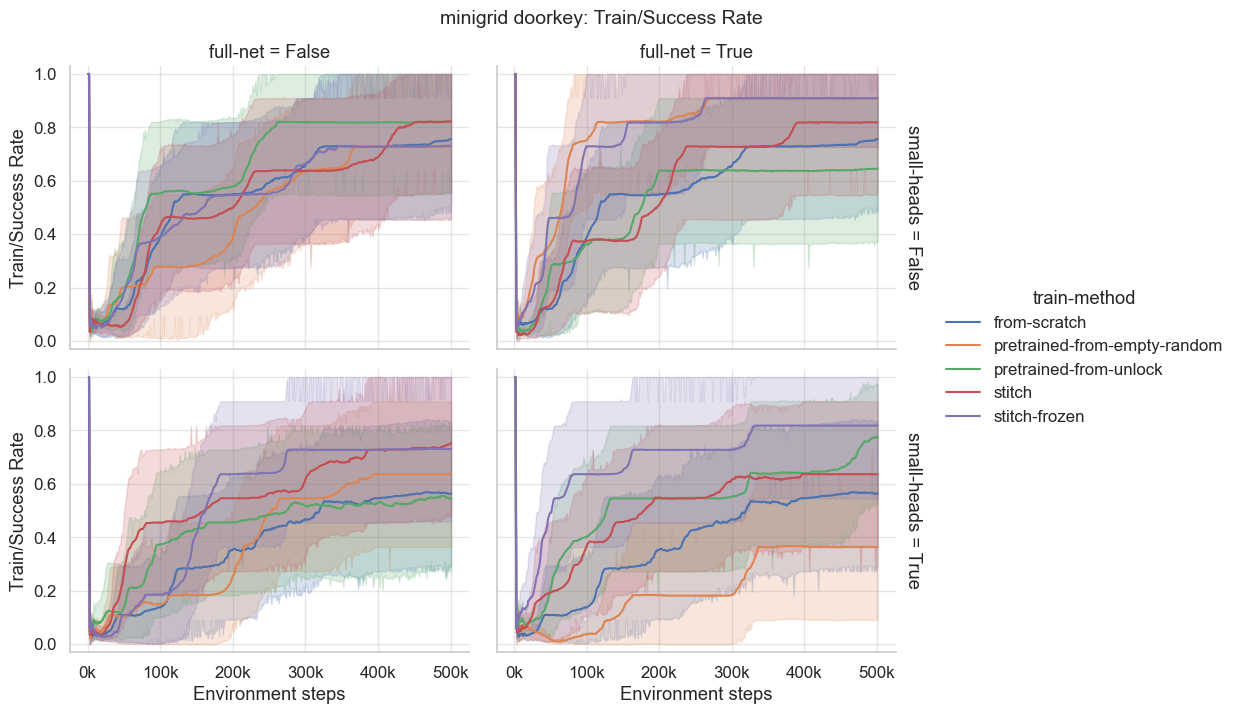

In [43]:
def plot_metric(df, y="Train/Success Rate", hue="train-method", row="small-heads", col="full-net",
                errorbar=("ci", 95), height=3.5, aspect=1.4, ylim=None, **kwargs):
    """ Plot one metric over the course of training, faceted by how the model was built. """
    data = df.dropna(subset=[y]).reset_index()
    grid = sns.relplot(data=data, x="Step", y=y, hue=hue, row=row, col=col, kind="line", errorbar=errorbar,
                       height=height, aspect=aspect, facet_kws={"margin_titles": True}, **kwargs)
    if ylim is None and 0 <= data[y].min() and data[y].max() <= 1:
        # A rate or a normalized return. Keep the error band from spilling into values the metric cannot take.
        ylim = (-0.03, 1.03)
    if ylim is not None:
        grid.set(ylim=ylim)
    grid.set_titles(row_template="{row_var} = {row_name}", col_template="{col_var} = {col_name}")
    grid.figure.suptitle(f"{BENCHMARK} {TASK}: {y}", y=1.02, fontsize=14)
    for ax in grid.axes.flat:
        ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
    grid.set_xlabels("Environment steps")
    return grid


plot_metric(plot_df, "Train/Success Rate")

The training success rate is a rolling average over the last 100 *training* episodes, so it reflects the
exploring behavior policy. `Eval/` metrics come from separate seeded episodes under a deterministic policy, and
are the ones to quote.

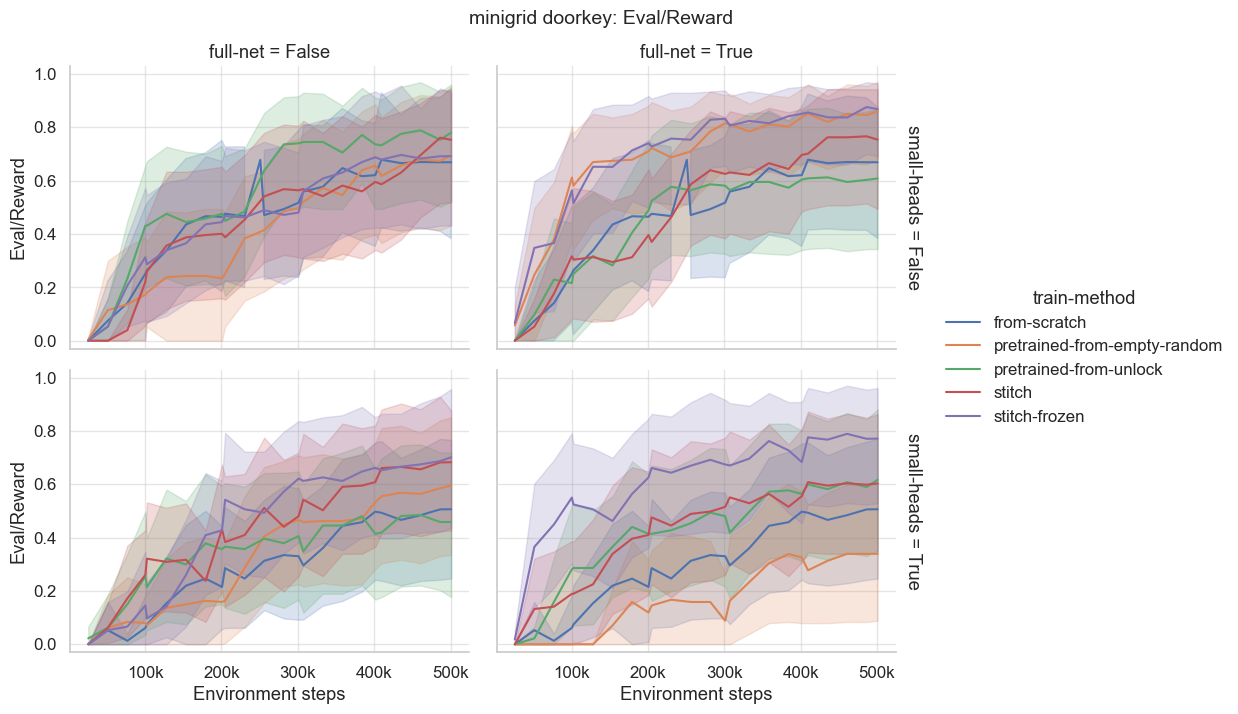

In [44]:
plot_metric(plot_df, "Eval/Reward")

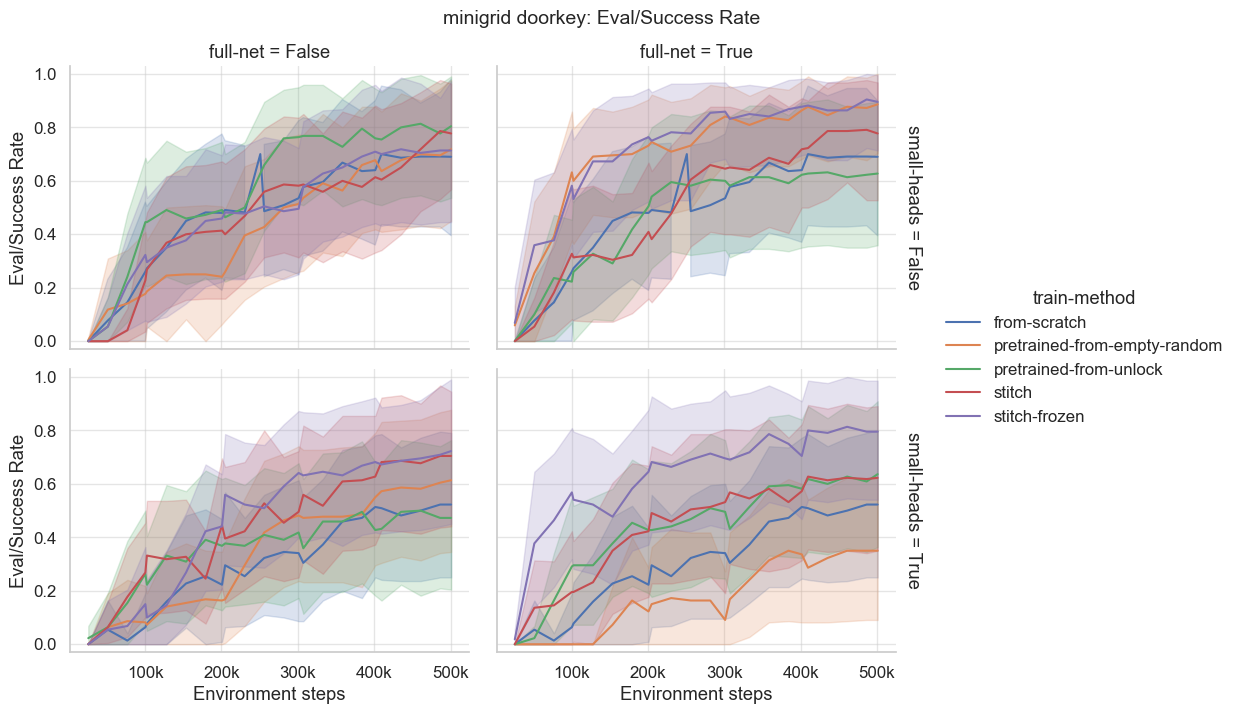

In [45]:
plot_metric(plot_df, "Eval/Success Rate")

Any recorded column can be plotted the same way -- `Entropy` is a useful one, since a collapse toward zero means
the policy stopped exploring.

['Entropy', 'Eval/Episode Length', 'Eval/Reward', 'Eval/Success Rate', 'Loss', 'Time/Eval Total', 'Time/FPS', 'Time/Step', 'Time/Total', 'Train/Episode Length', 'Train/Reward', 'Train/Success Rate']


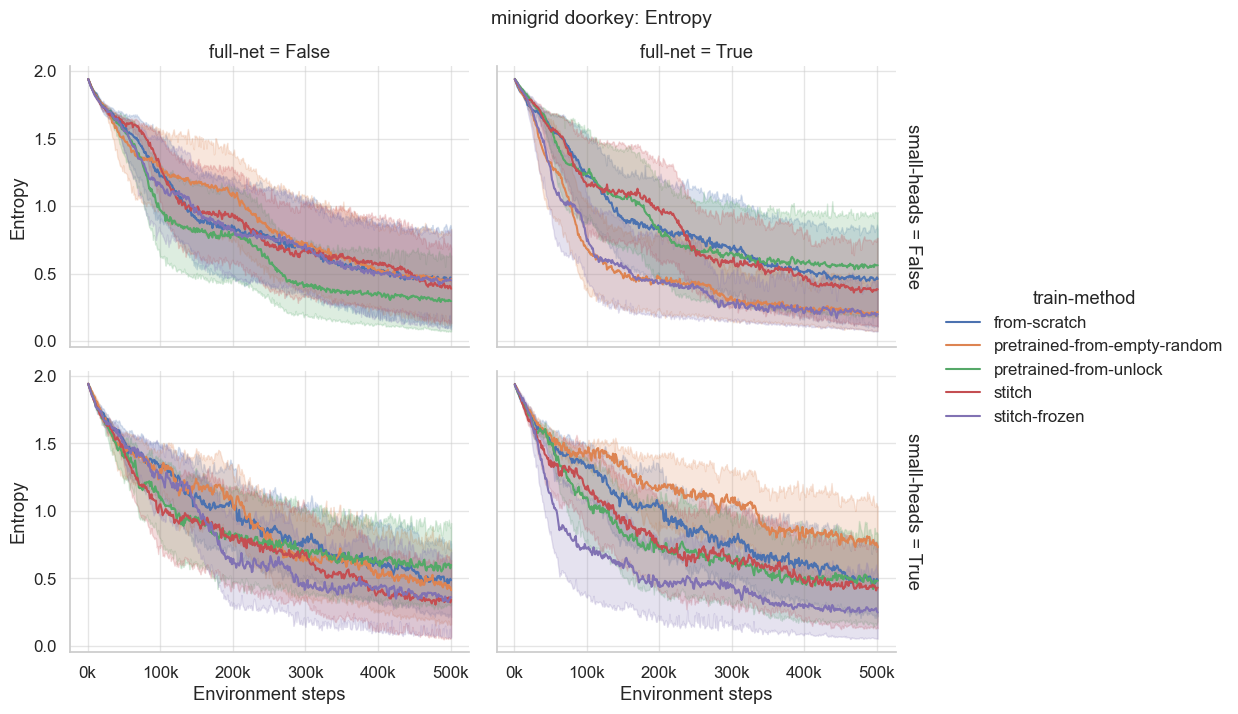

In [46]:
print(sorted(c for c in plot_df.columns if "/" in c or c in ("Loss", "Entropy")))
plot_metric(plot_df, "Entropy")